In [ ]:
# ============================================================================
# IMPROVED DA-BiGRU WIND SPEED FORECASTING SYSTEM
# Global Seeding + Physics-Informed Features
# ============================================================================

# @title Step 1: Setup, Seeding & Load Hourly Data
import os
import random
import numpy as np
import pandas as pd
import torch
from google.colab import drive
import warnings

warnings.filterwarnings('ignore')

# --- GLOBAL SEEDING FUNCTION ---
def seed_everything(seed=2026):
    """
    Sets seeds for all random number generators to ensure reproducible results.
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # For multi-GPU

    # Ensure deterministic behavior on CuDNN (GPU)
    # Note: This guarantees reproducibility but might be slightly slower
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"🔒 Global Seed set to: {seed}")

# Apply the seed immediately
SEED = 2026
seed_everything(SEED)

# 1. Mount Drive
print("📂 Mounting Google Drive...")
drive.mount('/content/drive')

# 2. Configuration
# UPDATE THIS PATH to where you saved merged_weather_data.csv
DATA_PATH = "/content/drive/MyDrive/Kanjikode/merged_weather_data.csv"
SEQ_LEN = 24        # 24 hours of context
BATCH_SIZE = 64     # Batch size
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"🖥️  Using Device: {DEVICE}")

# 3. Load Data
print(f"\n📉 Loading Dataset from: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)

# 4. Create Timestamp Index (Critical for Hourly Data)
df['timestamp'] = pd.to_datetime(df[['YEAR', 'MO', 'DY', 'HR']].rename(
    columns={'YEAR': 'year', 'MO': 'month', 'DY': 'day', 'HR': 'hour'}
))
df.set_index('timestamp', inplace=True)
df.sort_index(inplace=True)  # Ensure time is sorted

# Drop the breakdown columns now that we have index
df.drop(columns=['YEAR', 'MO', 'DY', 'HR'], inplace=True)

print(f"✅ Data Loaded. Shape: {df.shape}")
print(f"   Date Range: {df.index.min()} to {df.index.max()}")
print(f"   Total Hours: {len(df)}")

🔒 Global Seed set to: 2026
📂 Mounting Google Drive...
Mounted at /content/drive
🖥️  Using Device: cuda

📉 Loading Dataset from: /content/drive/MyDrive/Kanjikode/merged_weather_data.csv
✅ Data Loaded. Shape: (43848, 10)
   Date Range: 2020-01-01 00:00:00 to 2024-12-31 23:00:00
   Total Hours: 43848


In [ ]:
# @title Step 2: Feature Engineering & Data Splitting
import gc
from sklearn.preprocessing import MinMaxScaler

print("\n" + "="*60)
print("⚙️  STEP 2: FEATURE ENGINEERING & DATA SPLITTING")
print("="*60)

# 1. FIRST: Split Data (CRITICAL - Do this BEFORE feature engineering)
print("\n🔪 Splitting Data (80% Train / 20% Test)...")
train_size = int(len(df) * 0.8)

train_df_raw = df.iloc[:train_size].copy()
test_df_raw = df.iloc[train_size:].copy()

print(f"   Train: {train_df_raw.index[0]} to {train_df_raw.index[-1]}")
print(f"   Test:  {test_df_raw.index[0]} to {test_df_raw.index[-1]}")

# 2. Feature Engineering Function
def engineer_features(df_input):
    """
    Apply physics-based feature engineering.
    Rolling operations must be done AFTER split to prevent leakage.
    """
    df = df_input.copy()
    eps = 1e-6

    # A. Wind Shear (Logarithmic Wind Profile)
    df['WindShear'] = np.log((df['WS100M'] + eps) / (df['WS10M'] + eps)) / np.log(100 / 10)

    # B. Air Density (Ideal Gas Law: ρ = P/(R·T))
    T_kelvin = df['T2M'] + 273.15
    df['AirDensity'] = df['PS'] / (287.05 * T_kelvin)

    # C. Turbulence Intensity (Rolling window)
    roll = df['WS50M'].rolling(window=3, min_periods=1)
    df['TurbulenceIntensity'] = roll.std() / (roll.mean() + eps)
    df['TurbulenceIntensity'] = df['TurbulenceIntensity'].fillna(0)

    # D. Cyclical Time Encoding
    df['Hour_Sin'] = np.sin(2 * np.pi * df.index.hour / 24)
    df['Hour_Cos'] = np.cos(2 * np.pi * df.index.hour / 24)
    df['Month_Sin'] = np.sin(2 * np.pi * df.index.month / 12)
    df['Month_Cos'] = np.cos(2 * np.pi * df.index.month / 12)

    return df

print("\n⚙️  Engineering Features (Separately for Train and Test)...")
train_df_features = engineer_features(train_df_raw)
test_df_features = engineer_features(test_df_raw)

# 3. Select Features
feature_cols = [
    'WS50M', 'WS10M', 'WS100M', 'T2M', 'PS',
    'WindShear', 'AirDensity', 'TurbulenceIntensity',
    'Hour_Sin', 'Hour_Cos', 'Month_Sin', 'Month_Cos'
]

# Target Config
TARGET_COL_NAME = 'WS50M'
TARGET_COL_IDX = feature_cols.index(TARGET_COL_NAME)

train_df_final = train_df_features[feature_cols].copy()
test_df_final = test_df_features[feature_cols].copy()

# 4. Scaling (Fit ONLY on Train)
print("\n⚖️  Scaling Data...")
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df_final)   # ✅ Fit on train
test_scaled = scaler.transform(test_df_final)         # ✅ Transform test

print(f"✅ Data Processed.")
print(f"   Train Shape: {train_scaled.shape}")
print(f"   Test Shape:  {test_scaled.shape}")


⚙️  STEP 2: FEATURE ENGINEERING & DATA SPLITTING

🔪 Splitting Data (80% Train / 20% Test)...
   Train: 2020-01-01 00:00:00 to 2024-01-01 13:00:00
   Test:  2024-01-01 14:00:00 to 2024-12-31 23:00:00

⚙️  Engineering Features (Separately for Train and Test)...

⚖️  Scaling Data...
✅ Data Processed.
   Train Shape: (35078, 12)
   Test Shape:  (8770, 12)


In [ ]:
# @title Step 3: Baseline & Sequence Creation
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, r2_score

print("\n" + "="*60)
print("🧐 STEP 3: BASELINE & SEQUENCE CREATION")
print("="*60)

# 1. Establish Baseline (Persistence Model)
y_test_actual = test_scaled[1:, TARGET_COL_IDX]      # Actual Future
y_test_naive = test_scaled[:-1, TARGET_COL_IDX]      # Prediction = Current

mse_base = mean_squared_error(y_test_actual, y_test_naive)
r2_base = r2_score(y_test_actual, y_test_naive)


# 2. Create Sequences
def create_sequences(data, seq_len, target_col_idx=0):
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        x = data[i:(i+seq_len)]
        y = data[i+seq_len, target_col_idx]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

print("\n🔄 Creating Sequences...")
X_train, y_train = create_sequences(train_scaled, SEQ_LEN, TARGET_COL_IDX)
X_test, y_test = create_sequences(test_scaled, SEQ_LEN, TARGET_COL_IDX)

# 3. PyTorch DataLoaders (Seeding ensures deterministic shuffling)
train_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train)),
    batch_size=BATCH_SIZE, shuffle=True
)
test_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(y_test)),
    batch_size=BATCH_SIZE, shuffle=False
)

print(f"✅ DataLoaders Ready: Batch Size = {BATCH_SIZE}")


🧐 STEP 3: BASELINE & SEQUENCE CREATION

🔄 Creating Sequences...
✅ DataLoaders Ready: Batch Size = 64


In [ ]:
# @title Step 3.5: Save Processed Data to Drive
import joblib

SAVE_DIR = "/content/drive/MyDrive/Kanjikode/Processed_Data"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"\n💾 Saving Processed Data to: {SAVE_DIR}")

np.save(os.path.join(SAVE_DIR, 'X_train.npy'), X_train)
np.save(os.path.join(SAVE_DIR, 'y_train.npy'), y_train)
np.save(os.path.join(SAVE_DIR, 'X_test.npy'), X_test)
np.save(os.path.join(SAVE_DIR, 'y_test.npy'), y_test)

joblib.dump(scaler, os.path.join(SAVE_DIR, 'scaler.pkl'))

config = {
    'seq_len': SEQ_LEN,
    'batch_size': BATCH_SIZE,
    'feature_cols': feature_cols,
    'target_col_name': TARGET_COL_NAME,
    'target_col_idx': TARGET_COL_IDX,
    'train_size': train_size
}
joblib.dump(config, os.path.join(SAVE_DIR, 'config.pkl'))

print("✅ Data and Configuration Saved Successfully!")


💾 Saving Processed Data to: /content/drive/MyDrive/Kanjikode/Processed_Data
✅ Data and Configuration Saved Successfully!


In [ ]:
# @title Step 4: Define DA-BiGRU Architecture
import torch.nn as nn
import torch.nn.functional as F

print("\n" + "="*60)
print("🏗️  STEP 4: BUILDING DA-BiGRU MODEL")
print("="*60)

class FeatureAttention(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.Tanh(),
            nn.Linear(input_dim, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        weights = self.attn(x)
        return x * weights

class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x):
        weights = F.softmax(self.attn(x), dim=1)
        return torch.sum(x * weights, dim=1)

class DA_BiGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, n_layers=2, dropout=0.2):
        super().__init__()
        self.feat_attn = FeatureAttention(input_dim)
        self.gru = nn.GRU(
            input_dim, hidden_dim, num_layers=n_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if n_layers > 1 else 0
        )
        self.temp_attn = TemporalAttention(hidden_dim * 2)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.feat_attn(x)
        out, _ = self.gru(x)
        ctx = self.temp_attn(out)
        return self.fc(ctx)

# Initialize Model (Weights are deterministic due to seeding)
model = DA_BiGRU(input_dim=X_train.shape[2]).to(DEVICE)

print(f"✅ Model Initialized on {DEVICE}")


🏗️  STEP 4: BUILDING DA-BiGRU MODEL
✅ Model Initialized on cuda


In [ ]:
# @title Step 5: Train Model
import torch.optim as optim
import time

print("\n" + "="*60)
print("🚀 STEP 5: MODEL TRAINING")
print("="*60)

EPOCHS = 50
LEARNING_RATE = 0.001
PATIENCE = 10

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

best_val_loss = float('inf')
patience_counter = 0
train_losses, val_losses = [], []
start_time = time.time()

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer.zero_grad()
        pred = model(X_b).squeeze()
        loss = criterion(pred, y_b)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_b, y_b in test_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            pred = model(X_b).squeeze()
            val_loss += criterion(pred, y_b).item()

    avg_train = train_loss / len(train_loader)
    avg_val = val_loss / len(test_loader)

    train_losses.append(avg_train)
    val_losses.append(avg_val)

    scheduler.step(avg_val)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        elapsed = time.time() - start_time
        print(f"Epoch [{epoch+1:>3}/{EPOCHS}] | Train: {avg_train:.5f} | Val: {avg_val:.5f} | Time: {elapsed:.1f}s")

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save({'model_state_dict': model.state_dict(), 'epoch': epoch}, 'best_model.pth')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n🛑 Early Stopping at Epoch {epoch+1}")
            break

print(f"✅ Training Finished. Best Val Loss: {best_val_loss:.5f}")


🚀 STEP 5: MODEL TRAINING
Epoch [  1/50] | Train: 0.01193 | Val: 0.00104 | Time: 4.3s
Epoch [  5/50] | Train: 0.00124 | Val: 0.00066 | Time: 17.8s
Epoch [ 10/50] | Train: 0.00102 | Val: 0.00042 | Time: 33.0s
Epoch [ 15/50] | Train: 0.00092 | Val: 0.00045 | Time: 48.2s
Epoch [ 20/50] | Train: 0.00086 | Val: 0.00036 | Time: 63.6s
Epoch [ 25/50] | Train: 0.00086 | Val: 0.00043 | Time: 79.5s
Epoch [ 30/50] | Train: 0.00084 | Val: 0.00036 | Time: 94.6s
Epoch [ 35/50] | Train: 0.00082 | Val: 0.00033 | Time: 109.8s
Epoch [ 40/50] | Train: 0.00080 | Val: 0.00033 | Time: 124.9s
Epoch [ 45/50] | Train: 0.00079 | Val: 0.00032 | Time: 140.1s
Epoch [ 50/50] | Train: 0.00081 | Val: 0.00033 | Time: 155.7s
✅ Training Finished. Best Val Loss: 0.00032



🏆 STEP 6: FINAL EVALUATION WITH ADVANCED DIAGNOSTICS
   MAPE:  5.50%
   MAE:   0.1702 m/s
   RMSE:  0.2403 m/s
   R²:    0.9873

📈 Generating 6-Panel Diagnostic Dashboard...


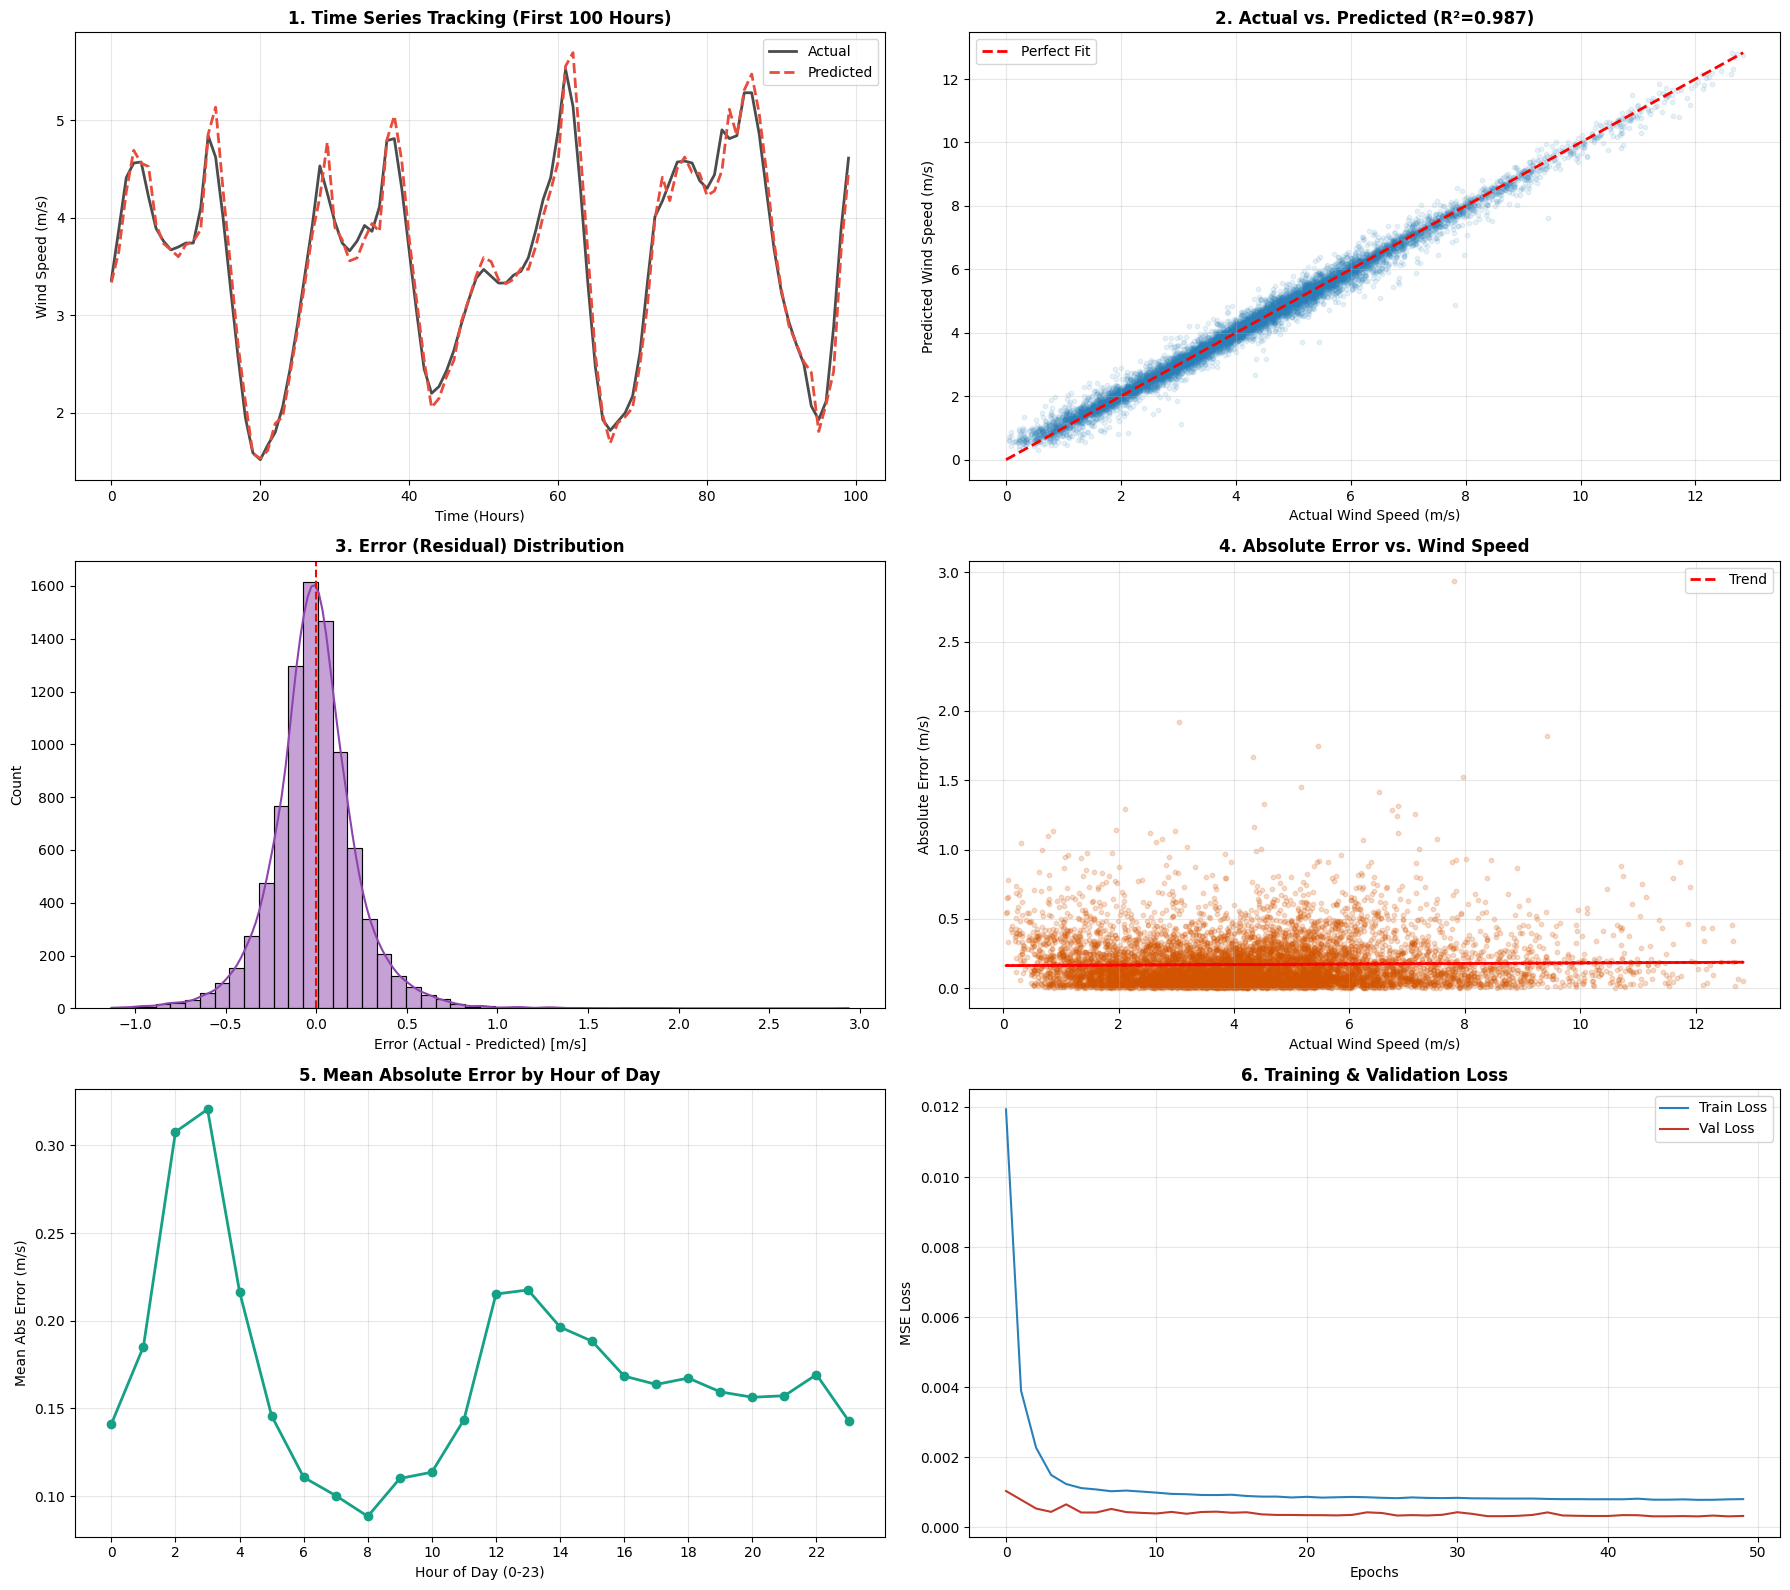


📊 DETAILED ERROR ANALYSIS
------------------------------

 Performance by Wind Category:
   Calm (0-2)     : MAE = 0.2018 m/s
   Light (2-5)    : MAE = 0.1508 m/s
   Moderate (5-8) : MAE = 0.1874 m/s
   High (8+)      : MAE = 0.1849 m/s

✅ Evaluation Complete.


In [ ]:
# @title Step 6: Final Evaluation with Advanced Graphs
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("\n" + "="*60)
print("🏆 STEP 6: FINAL EVALUATION WITH ADVANCED DIAGNOSTICS")
print("="*60)

# 1. Load Best Model
checkpoint = torch.load('best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# 2. Generate Predictions
preds, actuals = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        X_b = X_b.to(DEVICE)
        p = model(X_b).squeeze().cpu().numpy()
        preds.extend(p)
        actuals.extend(y_b.numpy())

preds = np.array(preds)
actuals = np.array(actuals)

# 3. Inverse Scaling
dummy_pred = np.zeros((len(preds), len(feature_cols)))
dummy_act = np.zeros((len(actuals), len(feature_cols)))
dummy_pred[:, TARGET_COL_IDX] = preds
dummy_act[:, TARGET_COL_IDX] = actuals

inv_pred = scaler.inverse_transform(dummy_pred)[:, TARGET_COL_IDX]
inv_act = scaler.inverse_transform(dummy_act)[:, TARGET_COL_IDX]

# 4. Re-align with Timestamps for Time-Based Analysis
# We need the original timestamps to analyze error by Hour of Day
try:
    # If df exists (from Step 1), use it
    timestamps = df.index[train_size + SEQ_LEN:]
except NameError:
    # If df is missing (e.g. restart), reload just the index
    print("⚠️ 'df' not found in memory. Reloading index for time analysis...")
    temp_df = pd.read_csv(DATA_PATH)
    temp_df['timestamp'] = pd.to_datetime(temp_df[['YEAR', 'MO', 'DY', 'HR']].rename(
        columns={'YEAR': 'year', 'MO': 'month', 'DY': 'day', 'HR': 'hour'}
    ))
    temp_df.sort_values('timestamp', inplace=True)
    timestamps = temp_df['timestamp'].iloc[train_size + SEQ_LEN:].values

# Ensure lengths match (trim if necessary due to batch drop_last=False)
limit = min(len(timestamps), len(inv_pred))
timestamps = timestamps[:limit]
inv_pred = inv_pred[:limit]
inv_act = inv_act[:limit]

# 5. Calculate Metrics
residuals = inv_act - inv_pred
mae = mean_absolute_error(inv_act, inv_pred)
rmse = np.sqrt(mean_squared_error(inv_act, inv_pred))
r2 = r2_score(inv_act, inv_pred)

# Valid MAPE (> 0.5 m/s)
valid_mask = inv_act > 0.5
mape = np.mean(np.abs((inv_act[valid_mask] - inv_pred[valid_mask]) / inv_act[valid_mask])) * 100

print(f"   MAPE:  {mape:.2f}%")
print(f"   MAE:   {mae:.4f} m/s")
print(f"   RMSE:  {rmse:.4f} m/s")
print(f"   R²:    {r2:.4f}")

# ============================================================================
# 📊 VISUALIZATION DASHBOARD (6 PANELS)
# ============================================================================
print("\n📈 Generating 6-Panel Diagnostic Dashboard...")

fig, axes = plt.subplots(3, 2, figsize=(18, 16))
plt.subplots_adjust(hspace=0.3, wspace=0.2)

# Plot 1: Time Series Zoom (First 100 Hrs)
# Visualizes how well the model tracks the sequence
ax = axes[0, 0]
ax.plot(inv_act[:100], label='Actual', color='black', lw=2, alpha=0.7)
ax.plot(inv_pred[:100], label='Predicted', color='#e74c3c', linestyle='--', lw=2)
ax.set_title('1. Time Series Tracking (First 100 Hours)', fontweight='bold')
ax.set_ylabel('Wind Speed (m/s)')
ax.set_xlabel('Time (Hours)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Scatter Plot (Actual vs Predicted)
# Checks for bias (is it always under-predicting high winds?)
ax = axes[0, 1]
ax.scatter(inv_act, inv_pred, alpha=0.1, s=10, color='#2980b9')
max_val = max(inv_act.max(), inv_pred.max())
ax.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect Fit')
ax.set_title(f'2. Actual vs. Predicted (R²={r2:.3f})', fontweight='bold')
ax.set_xlabel('Actual Wind Speed (m/s)')
ax.set_ylabel('Predicted Wind Speed (m/s)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Residual Distribution
# Checks if errors are normal (Gaussian) and centered at zero
ax = axes[1, 0]
sns.histplot(residuals, kde=True, ax=ax, color='#8e44ad', bins=50)
ax.axvline(0, color='red', linestyle='--')
ax.set_title('3. Error (Residual) Distribution', fontweight='bold')
ax.set_xlabel('Error (Actual - Predicted) [m/s]')

# Plot 4: Error by Wind Speed
# Critical: Does the model fail at high wind speeds?
ax = axes[1, 1]
ax.scatter(inv_act, np.abs(residuals), alpha=0.2, s=10, color='#d35400')
# Add trendline
z = np.polyfit(inv_act, np.abs(residuals), 1)
p = np.poly1d(z)
ax.plot(inv_act, p(inv_act), "r--", lw=2, label='Trend')
ax.set_title('4. Absolute Error vs. Wind Speed', fontweight='bold')
ax.set_xlabel('Actual Wind Speed (m/s)')
ax.set_ylabel('Absolute Error (m/s)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 5: Diurnal Error Profile (Error by Hour of Day)
# Critical: Is the model worse at night or day?
ax = axes[2, 0]
# Create a temporary DataFrame for grouping
df_viz = pd.DataFrame({'hour': pd.to_datetime(timestamps).hour, 'abs_error': np.abs(residuals)})
hourly_error = df_viz.groupby('hour')['abs_error'].mean()
ax.plot(hourly_error.index, hourly_error.values, marker='o', linestyle='-', color='#16a085', lw=2)
ax.set_title('5. Mean Absolute Error by Hour of Day', fontweight='bold')
ax.set_xlabel('Hour of Day (0-23)')
ax.set_ylabel('Mean Abs Error (m/s)')
ax.set_xticks(range(0, 24, 2))
ax.grid(True, alpha=0.3)

# Plot 6: Training History
# Did the model converge properly?
ax = axes[2, 1]
ax.plot(train_losses, label='Train Loss', color='#2980b9')
ax.plot(val_losses, label='Val Loss', color='#c0392b')
ax.set_title('6. Training & Validation Loss', fontweight='bold')
ax.set_xlabel('Epochs')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# 📋 DETAILED PERFORMANCE REPORT
# ============================================================================
print("\n📊 DETAILED ERROR ANALYSIS")
print("-" * 30)

# 1. Error by Range
bins = [0, 2, 5, 8, 100]
labels = ['Calm (0-2)', 'Light (2-5)', 'Moderate (5-8)', 'High (8+)']
df_viz['speed_bin'] = pd.cut(inv_act, bins=bins, labels=labels)
range_mae = df_viz.groupby('speed_bin')['abs_error'].mean()

print("\n Performance by Wind Category:")
for label in labels:
    if label in range_mae:
        print(f"   {label:<15}: MAE = {range_mae[label]:.4f} m/s")



print("\n✅ Evaluation Complete.")

In [ ]:
# @title Step 7: Save Complete Model Package
print("\n💾 Saving Complete Model Package...")

MODEL_SAVE_DIR = "/content/drive/MyDrive/Kanjikode/Final_Model"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

final_package = {
    'model_state_dict': model.state_dict(),
    'scaler': scaler,
    'config': config,
    'metrics': {'mape': mape, 'mae': mae, 'rmse': rmse, 'r2': r2}
}

torch.save(final_package, os.path.join(MODEL_SAVE_DIR, 'complete_model_package.pth'))
print(f"✅ Complete model package saved to: {MODEL_SAVE_DIR}")


💾 Saving Complete Model Package...
✅ Complete model package saved to: /content/drive/MyDrive/Kanjikode/Final_Model
